In [1]:
# Necessary packages
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# Force the system to ignore all deprecation warnings
warnings.filterwarnings('ignore')

In [2]:
tickers = ['HG=F', 'CL=F', '^GSPC', 'SI=F', 'GC=F', 'DX-Y.NYB', 'ZW=F', 'ZC=F']

# Download historical close prices from 2000 to the end of 2025
raw_data = yf.download(tickers, start='2000-08-30', end='2026-01-01')['Close']

# Initialize the pipeline
clean_df = raw_data.copy()
# Dictionary to map confusing ticker symbols to readable dashboard asset names
column_mapping = {
    'HG=F': 'Copper',
    'CL=F': 'Crude_Oil',
    '^GSPC': 'SP500',
    'SI=F': 'Silver',
    'GC=F': 'Gold',
    'DX-Y.NYB': 'US_Dollar_Index',
    'ZW=F': 'Wheat',
    'ZC=F': 'Corn'
}

# Execute the column rename operation directly on the dataframe
clean_df.rename(columns=column_mapping, inplace=True)

[*********************100%***********************]  8 of 8 completed


In [3]:
# Count missing values (NaN) caused by asynchronous market holidays
missing_values = clean_df.isna().sum()
print("--- Total NaN Values Per Asset ---")
print(missing_values)

--- Total NaN Values Per Asset ---
Ticker
Crude_Oil          48
US_Dollar_Index    12
Gold               52
Copper             47
Silver             50
Corn               72
Wheat              60
SP500              38
dtype: int64


In [4]:
# Count absolute zero prices which will crash return calculations
zero_prices = (clean_df == 0).sum()
print("\n--- Total 0 Values Per Asset ---")
print(zero_prices)


--- Total 0 Values Per Asset ---
Ticker
Crude_Oil          0
US_Dollar_Index    0
Gold               0
Copper             0
Silver             0
Corn               0
Wheat              0
SP500              0
dtype: int64


In [5]:
# Detect historical negative prices (e.g., April 2020 Crude Oil crash)
negative_prices = (clean_df < 0).sum()
print("\n--- Total Negative Values Per Asset ---")
print(negative_prices)


--- Total Negative Values Per Asset ---
Ticker
Crude_Oil          1
US_Dollar_Index    0
Gold               0
Copper             0
Silver             0
Corn               0
Wheat              0
SP500              0
dtype: int64


In [6]:
# Patch asynchronous market holiday gaps by carrying the last valid price forward
clean_df.ffill(inplace=True)
# Drop any lingering NaNs at the absolute top of the timeline
clean_df.dropna(inplace=True)
# Floor extreme negative anomalies (like 2020 Crude Oil) to a near-zero positive float
clean_df[clean_df < 0] = 0.01

In [7]:
# Display the absolute dimensions of the matrix (Total Rows/Days, Total Columns/Assets)
print("--- Matrix Dimensions (Rows, Columns) ---")
print(clean_df.shape)

# Generate a quantitative summary (Mean, Std Dev, Min, Max, Quartiles)
print("\n--- Core Statistical Summary ---")
print(clean_df.describe())

--- Matrix Dimensions (Rows, Columns) ---
(6410, 8)

--- Core Statistical Summary ---
Ticker    Crude_Oil  US_Dollar_Index         Gold       Copper       Silver  \
count   6410.000000      6410.000000  6410.000000  6410.000000  6410.000000   
mean      64.504481        92.519660  1245.880748     2.833006    17.883565   
std       24.599427        11.200471   730.600438     1.177004     9.687522   
min        0.010000        71.330002   255.100006     0.604000     4.026000   
25%       46.157499        82.532499   641.624985     2.115000    11.854000   
50%       63.504999        92.959999  1246.000000     3.036750    16.954499   
75%       81.769997        99.577501  1675.450012     3.677000    23.454999   
max      145.289993       120.900002  4529.100098     5.795000    77.374001   

Ticker         Corn        Wheat        SP500  
count   6410.000000  6410.000000  6410.000000  
mean     411.132644   537.122270  2286.863285  
std      156.944657   178.838558  1467.169412  
min      1

In [8]:
# Verify data types and confirm the structural integrity of the dataframe
print("\n--- System Information & Memory Usage ---")
clean_df.info()


--- System Information & Memory Usage ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6410 entries, 2000-08-30 to 2025-12-31
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crude_Oil        6410 non-null   float64
 1   US_Dollar_Index  6410 non-null   float64
 2   Gold             6410 non-null   float64
 3   Copper           6410 non-null   float64
 4   Silver           6410 non-null   float64
 5   Corn             6410 non-null   float64
 6   Wheat            6410 non-null   float64
 7   SP500            6410 non-null   float64
dtypes: float64(8)
memory usage: 450.7 KB


In [9]:
# Save as CSV for the backend
clean_df.to_csv('market_data_2000_2025.csv', index=True)

---
## Exploratory Data Analysis
- **Plot 1** — Normalised price performance (base 100)
- **Plot 2** — Pearson correlation heatmap
- **Plot 3** — Annual returns heatmap
- **Plot 4** — Per-asset summary stats (total return, volatility, max drawdown)

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.ticker as mticker

# ── Shared config ─────────────────────────────────────────────────────────────
ASSETS = ['Crude_Oil', 'US_Dollar_Index', 'Gold', 'Copper', 'Silver', 'Corn', 'Wheat', 'SP500']

LABELS = {
    'Crude_Oil':       'Crude Oil',
    'US_Dollar_Index': 'USD Index',
    'Gold':            'Gold',
    'Copper':          'Copper',
    'Silver':          'Silver',
    'Corn':            'Corn',
    'Wheat':           'Wheat',
    'SP500':           'S&P 500',
}

COLORS = {
    'Crude_Oil':       '#BA7517',
    'US_Dollar_Index': '#378ADD',
    'Gold':            '#EF9F27',
    'Copper':          '#D85A30',
    'Silver':          '#888780',
    'Corn':            '#639922',
    'Wheat':           '#1D9E75',
    'SP500':           '#7F77DD',
}

plt.rcParams.update({
    'font.family':        'sans-serif',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         '#e5e5e5',
    'grid.linewidth':     0.6,
})

# ── Derived series (reused across all plots) ──────────────────────────────────
# Normalised prices — base 100 at first row, resampled monthly for readability
normalised = (clean_df / clean_df.iloc[0] * 100).resample('ME').last()

# Log returns for annualised volatility
log_ret = np.log(clean_df / clean_df.shift(1))

# Annual returns: year-end prices, pct change, integer year index
annual = clean_df.resample('YE').last().pct_change().dropna() * 100
annual.index = annual.index.year

# Per-asset stats
stats = {}
for col in ASSETS:
    total_ret = (clean_df[col].iloc[-1] / clean_df[col].iloc[0] - 1) * 100
    ann_vol   = log_ret[col].std() * np.sqrt(252) * 100
    roll_max  = clean_df[col].cummax()
    max_dd    = ((clean_df[col] - roll_max) / roll_max * 100).min()
    stats[col] = dict(total_return=total_ret, ann_vol=ann_vol, max_drawdown=max_dd)

stats_df = pd.DataFrame(stats).T
print(stats_df.round(2))

                 total_return  ann_vol  max_drawdown
Crude_Oil               71.92   206.44        -99.99
US_Dollar_Index        -12.36     7.71        -41.00
Gold                  1479.26    17.34        -44.36
Copper                 536.16    27.20        -69.41
Silver                1322.60    31.53        -75.85
Corn                   142.56    28.36        -63.73
Wheat                  105.89    32.13        -71.80
SP500                  355.58    19.25        -56.78


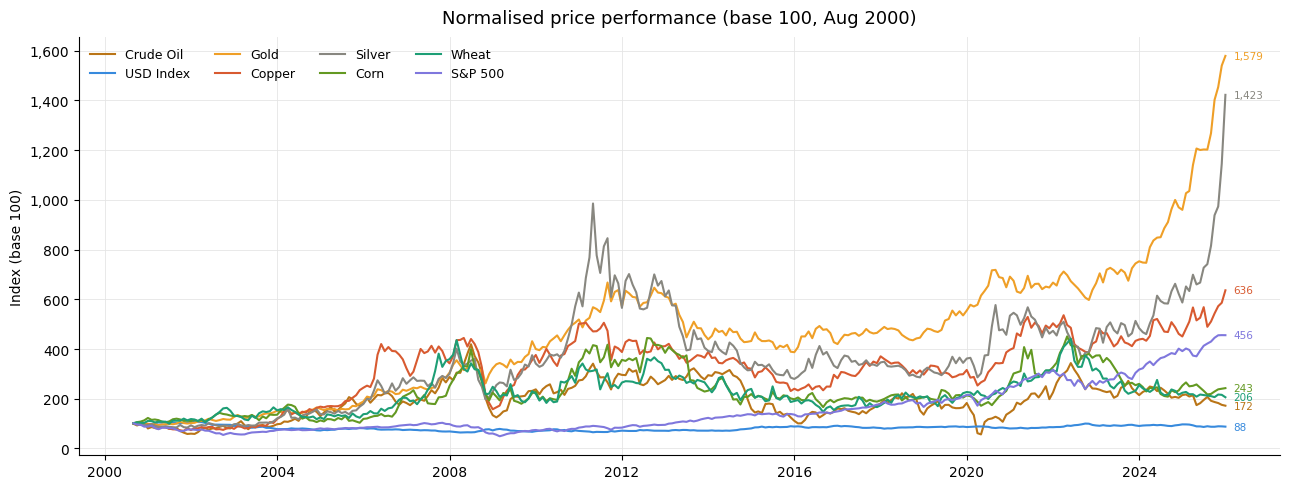

In [11]:
# ── Plot 1: Normalised price performance ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

for asset in ASSETS:
    ax.plot(
        normalised.index,
        normalised[asset],
        label=LABELS[asset],
        color=COLORS[asset],
        linewidth=1.5,
    )

ax.set_title('Normalised price performance (base 100, Aug 2000)', fontsize=13, pad=10)
ax.set_ylabel('Index (base 100)')
ax.legend(ncol=4, fontsize=9, frameon=False, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Annotate final values at the right edge
for asset in ASSETS:
    y_end = normalised[asset].iloc[-1]
    ax.annotate(
        f'{y_end:,.0f}',
        xy=(normalised.index[-1], y_end),
        xytext=(6, 0), textcoords='offset points',
        fontsize=7.5, color=COLORS[asset], va='center',
    )

plt.tight_layout()
plt.savefig('plot1_performance.png', dpi=150, bbox_inches='tight')
plt.show()

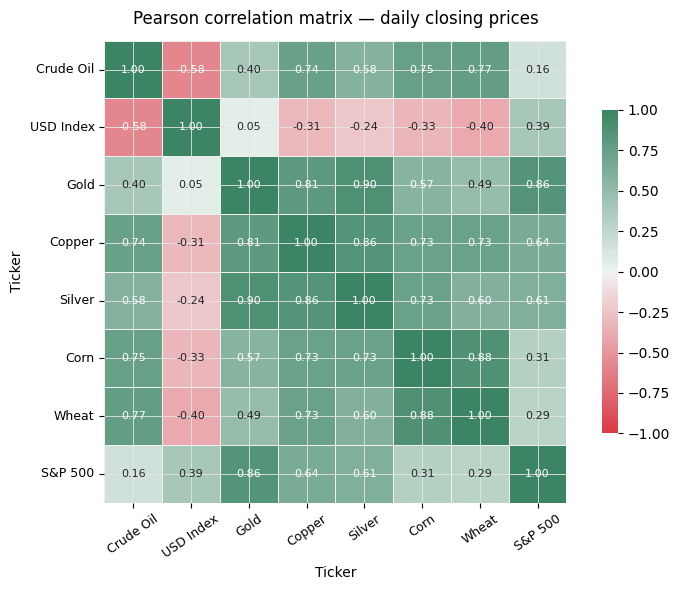

In [12]:
# ── Plot 2: Pearson correlation heatmap ───────────────────────────────────────
corr = clean_df[ASSETS].corr()
tick_labels = [LABELS[a] for a in ASSETS]

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    ax=ax,
    annot=True, fmt='.2f',
    cmap=sns.diverging_palette(10, 150, as_cmap=True),
    center=0, vmin=-1, vmax=1,
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    linewidths=0.4, linecolor='#f0f0f0',
    annot_kws={'size': 8},
    square=True,
    cbar_kws={'shrink': 0.7},
)

ax.set_title('Pearson correlation matrix — daily closing prices', fontsize=12, pad=12)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('plot2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

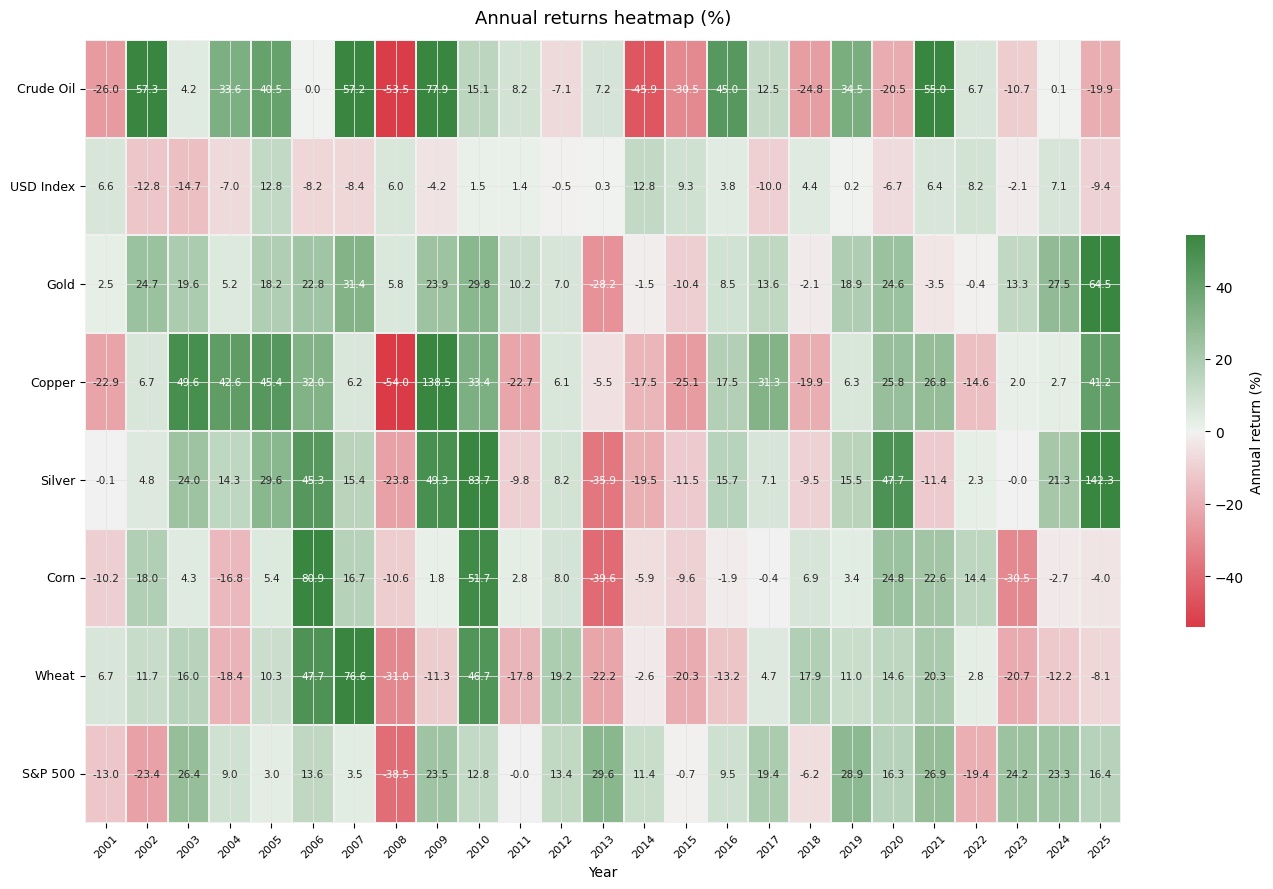

In [13]:
# ── Plot 3: Annual returns heatmap ────────────────────────────────────────────
annual_plot = annual[ASSETS].rename(columns=LABELS)   # assets as columns, years as rows

# Cap colour scale at 95th percentile of absolute values to avoid outliers
# dominating the palette (e.g. Copper +138% in 2009)
abs_max = np.nanpercentile(np.abs(annual_plot.values), 95)

fig, ax = plt.subplots(figsize=(14, 9))

sns.heatmap(
    annual_plot.T,           # transpose: assets as rows, years as columns
    ax=ax,
    annot=True, fmt='.1f',
    cmap=sns.diverging_palette(10, 130, as_cmap=True),
    center=0, vmin=-abs_max, vmax=abs_max,
    linewidths=0.3, linecolor='#f0f0f0',
    annot_kws={'size': 7.5},
    cbar_kws={'shrink': 0.5, 'label': 'Annual return (%)'},
)

ax.set_title('Annual returns heatmap (%)', fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('plot3_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()

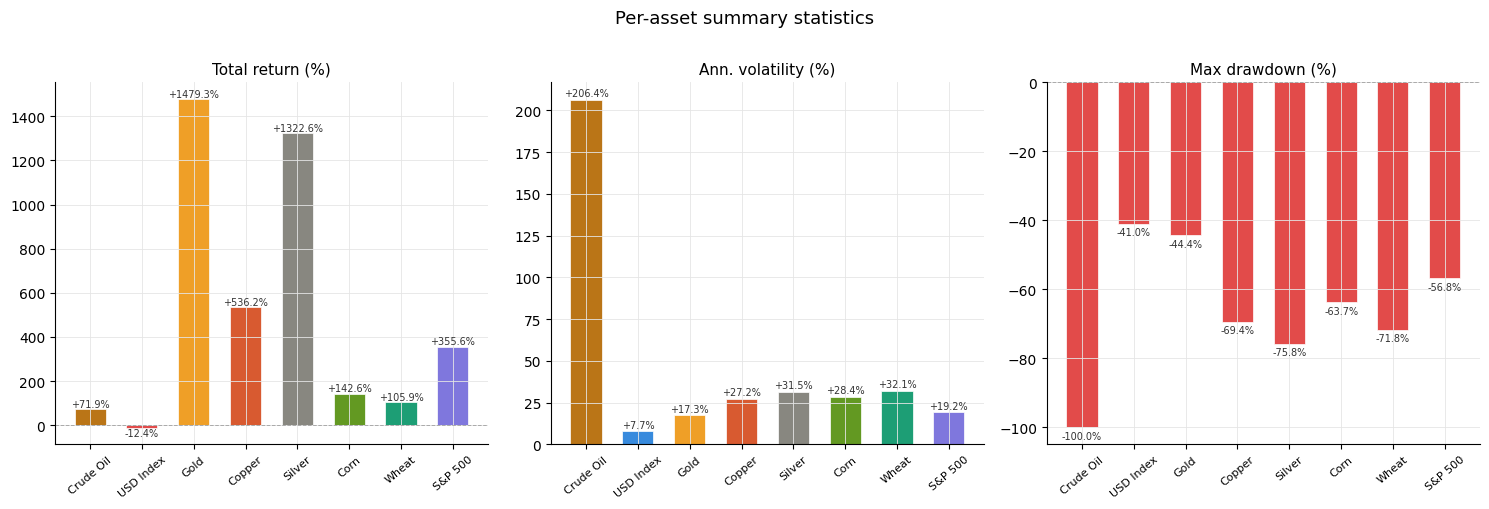

In [14]:
# ── Plot 4: Per-asset summary stats ──────────────────────────────────────────
metrics       = ['total_return', 'ann_vol', 'max_drawdown']
metric_labels = ['Total return (%)', 'Ann. volatility (%)', 'Max drawdown (%)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, title in zip(axes, metrics, metric_labels):
    values = [stats[a][metric] for a in ASSETS]
    colors = [
        COLORS[a] if stats[a][metric] >= 0 else '#E24B4A'
        for a in ASSETS
    ]
    bars = ax.bar(
        [LABELS[a] for a in ASSETS],
        values,
        color=colors,
        edgecolor='white',
        linewidth=0.5,
        width=0.6,
    )
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.axhline(0, color='#aaa', linewidth=0.7, linestyle='--')

    # Value labels on each bar
    for bar, val in zip(bars, values):
        va  = 'bottom' if val >= 0 else 'top'
        off = 1 if val >= 0 else -1
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + off,
            f'{val:+.1f}%',
            ha='center', va=va, fontsize=7, color='#333',
        )

fig.suptitle('Per-asset summary statistics', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plot4_stats.png', dpi=150, bbox_inches='tight')
plt.show()